# Q2 example-plot figure -- plan

**New, separate notebook (not added to `results_figures_q2_rq3.ipynb`)**: that notebook already
runs a per-plot SHAP grid for the 8 known worst-residual outlier plots (Figure 3 extension), built
specifically to show those plots are NOT explained by Set4's features (1-17% explained, evidence
for the target-construction-artifact story). This notebook needs the OPPOSITE selection criterion
-- a plot that IS well explained, to illustrate what Q2's attribution target and mechanism look
like when they work as intended -- so it is kept separate to avoid confusing the two purposes,
following the same convention as `results_figures_q3_rq1.ipynb`'s standalone PINN example-plot
section.

**Figure in this notebook**

| Figure | Question it answers |
|---|---|
| Q2 example plot | What does one plot's own $\Delta y_{\max}$ actually look like -- its observed trajectory, its own fitted ceiling vs. the yield-class ceiling -- and which Set4 variables does XGBoost's SHAP attribute that gap to? |

**Data**: `outputs/spatial_block_kfold/rq3_en_xgb_nested_set4_gated_all_vif/4survey/predictions.csv`
(target + coordinates), `.../xgboost_shap_values.csv` (per-plot, per-feature SHAP, all 56,114
plots -- not just the outlier subset), `data/processed/growth_curve/4survey/growth_curve_table.parquet`
(per-survey Age/Top_Height95/yldc/p1-p5/y_max_yldc, for the trajectory panel). No new fitting or
retraining -- everything read from already-saved outputs, same convention as every other figure
in this project.

**Selection criterion** (the opposite of the outlier-grid notebook's): exclude Tukey-fence-flagged
plots (Q2's own outlier-audit rule); require the plot's XGBoost SHAP values to sum close to its
actual $\Delta y_{\max}$ (well-explained, not a target-construction artifact); require a moderate
(not extreme) deviation size; require at least 4 survey observations; prefer a SHAP breakdown with
one or two clearly dominant features (interpretable, not a diffuse 20-variable mess).

**Style / uncertainty convention**: see `notebooks/results_figures_style.py`. Single illustrative
example, not a claim of representativeness -- same framing as the Q3 PINN example-plot figure.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks: walk upward
# until a folder containing both README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks.results_figures_style import COLOR_XGBOOST, COLOR_NEUTRAL_EDGE, DIVERGING_CMAP, apply_rcparams

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results" / "q2"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Q2_OUTPUT_DIR = project_root / "outputs" / "spatial_block_kfold" / "rq3_en_xgb_nested_set4_gated_all_vif" / "4survey"
GROWTH_CURVE_TABLE = project_root / "data" / "processed" / "growth_curve" / "4survey" / "growth_curve_table.parquet"

## Selecting an example plot

Same Tukey-fence rule Q2's own methodology uses to flag extreme/artifact-suspect plots
(Equation~\ref{eq:tukey-fences} in the dissertation) -- excluded here for the OPPOSITE reason the
outlier-grid notebook uses them: there, flagged plots are the whole point; here, they are excluded
so the example is not accidentally a known target-construction artifact.

In [3]:
predictions = pd.read_csv(Q2_OUTPUT_DIR / "predictions.csv")
shap_values = pd.read_csv(Q2_OUTPUT_DIR / "xgboost_shap_values.csv")
growth_curve_table = pd.read_parquet(GROWTH_CURVE_TABLE)

# --- Tukey-fence flag, same rule as Q2's own target/outlier audit (Equation eq:tukey-fences) ---
q1, q3 = predictions["local_y_max_difference"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
predictions["tukey_flagged"] = (
    (predictions["local_y_max_difference"] < lower_fence) | (predictions["local_y_max_difference"] > upper_fence)
)
print(f"Tukey-flagged: {predictions['tukey_flagged'].sum():,} of {len(predictions):,} plots")

# --- SHAP sum vs. actual deviation, and how concentrated the SHAP breakdown is ---
shap_feature_columns = [c for c in shap_values.columns if c not in ("identification", "fold")]
shap_values["shap_sum"] = shap_values[shap_feature_columns].sum(axis=1)
shap_values["top1_share"] = (
    shap_values[shap_feature_columns].abs().max(axis=1) / shap_values[shap_feature_columns].abs().sum(axis=1)
)

survey_counts = growth_curve_table.groupby("identification").size().rename("n_surveys")

candidates = (
    predictions.merge(shap_values[["identification", "shap_sum", "top1_share"]], on="identification")
    .merge(survey_counts, on="identification")
)
candidates = candidates[~candidates["tukey_flagged"]].copy()
candidates["explained_pct"] = candidates["shap_sum"] / candidates["local_y_max_difference"] * 100
candidates["same_sign"] = np.sign(candidates["shap_sum"]) == np.sign(candidates["local_y_max_difference"])
candidates["abs_actual"] = candidates["local_y_max_difference"].abs()

# Moderate deviation: between the 40th and 75th percentile of |actual deviation| among
# non-flagged plots -- illustrative, not a headline-grabbing extreme value.
deviation_lo, deviation_hi = candidates["abs_actual"].quantile([0.40, 0.75])
shortlist = candidates[
    candidates["same_sign"]
    & candidates["explained_pct"].between(70, 130)
    & candidates["abs_actual"].between(deviation_lo, deviation_hi)
    & (candidates["n_surveys"] >= 4)
    & (candidates["top1_share"] > 0.25)
].copy()
shortlist["closeness_to_100pct_explained"] = -(shortlist["explained_pct"] - 100).abs()
shortlist = shortlist.sort_values("closeness_to_100pct_explained", ascending=False)
print(f"\nShortlist: {len(shortlist)} candidates meeting all criteria")
print(shortlist[["identification", "cpmt", "local_y_max_difference", "explained_pct", "top1_share", "n_surveys"]].head(10).to_string(index=False))

Tukey-flagged: 954 of 56,114 plots

Shortlist: 2473 candidates meeting all criteria
 identification  cpmt  local_y_max_difference  explained_pct  top1_share  n_surveys
         142910  2016               -9.072399     100.007061    0.363458          4
         118468  2260                5.985529      99.990199    0.602138          4
         138829  2150              -10.155198      99.974868    0.448191          4
         160373  2010              -11.038630     100.031478    0.530293          4
         161151  2148               -7.467317      99.929521    0.600710          4
         309770  1107               10.218906     100.086680    0.355726          4
         146009  2095               -8.290135      99.904019    0.367756          4
         132791  2098               -7.857138      99.898898    0.402034          4
         230630  2197                6.749179      99.869139    0.535853          4
         119756  2094              -10.735721      99.867547    0.467682    

**Chosen: plot 309770.** A mature stand (observed ages 66-81, past the fast-establishment phase,
closer to the region where a curve fit is well-conditioned -- avoids the immature-trajectory
reliability caveat Methodology raises for young stands). $\Delta y_{\max}=+10.2$m; XGBoost's raw
prediction is +12.4m ($|$residual$|$=2.2m -- confirmed against the population below to sit in
roughly the best 19th percentile of non-flagged plots, not literally perfect but well above
typical). % AUDIT: an earlier pass of this notebook reported "99.9% explained" using the SUM of
SHAP values against the actual deviation -- that sum excludes the model's own base/expected
value, so it is not the same thing as the raw prediction and overstated how well this specific
plot is predicted. Corrected here and in the figure title below to use the actual prediction
(observed - predicted), the same metric the "how typical" quantification section already uses.
Unlike most of this dissertation's examples, the two largest SHAP drivers here are genuine
environmental variables (`chelsa_bio12_precip_mm`, `windward_topex`), not CanopyCover (which is
small here, -0.8m) -- a more interesting illustration of the environmental-attribution mechanism
than a CanopyCover-dominated example would be, given how much of Q1/Q2's own text already covers
the CanopyCover-dominance finding.

In [4]:
EXAMPLE_PLOT_ID = 309770

trajectory = growth_curve_table[growth_curve_table["identification"] == EXAMPLE_PLOT_ID].sort_values("Age")
p4, p5 = trajectory["p4"].iloc[0], trajectory["p5"].iloc[0]
y_max_yldc = trajectory["y_max_yldc"].iloc[0]

# Plot's own fitted ceiling, Equation eq:plot-ymax-fit -- OLS through the origin using this
# plot's own p4/p5 (held fixed, per Q2's methodology) and its own observed Age/Top_Height95 pairs.
growth_term = (1 - np.exp(-p4 * trajectory["Age"])) ** p5
y_max_hat = (trajectory["Top_Height95"] * growth_term).sum() / (growth_term ** 2).sum()

delta_y_max = y_max_hat - y_max_yldc
print(f"Plot {EXAMPLE_PLOT_ID}: observed ages {list(trajectory['Age'])}")
print(f"y_max_hat (own fitted ceiling) = {y_max_hat:.2f}m")
print(f"y_max_yldc (yield-class ceiling) = {y_max_yldc:.2f}m")
print(f"delta_y_max (recomputed here) = {delta_y_max:.2f}m")
print(f"local_y_max_difference (saved in predictions.csv) = "
      f"{predictions.loc[predictions['identification'] == EXAMPLE_PLOT_ID, 'local_y_max_difference'].iloc[0]:.2f}m "
      "-- cross-check, should match the recomputed value above")

Plot 309770: observed ages [66, 70, 79, 81]
y_max_hat (own fitted ceiling) = 42.99m
y_max_yldc (yield-class ceiling) = 32.77m
delta_y_max (recomputed here) = 10.22m
local_y_max_difference (saved in predictions.csv) = 10.22m -- cross-check, should match the recomputed value above


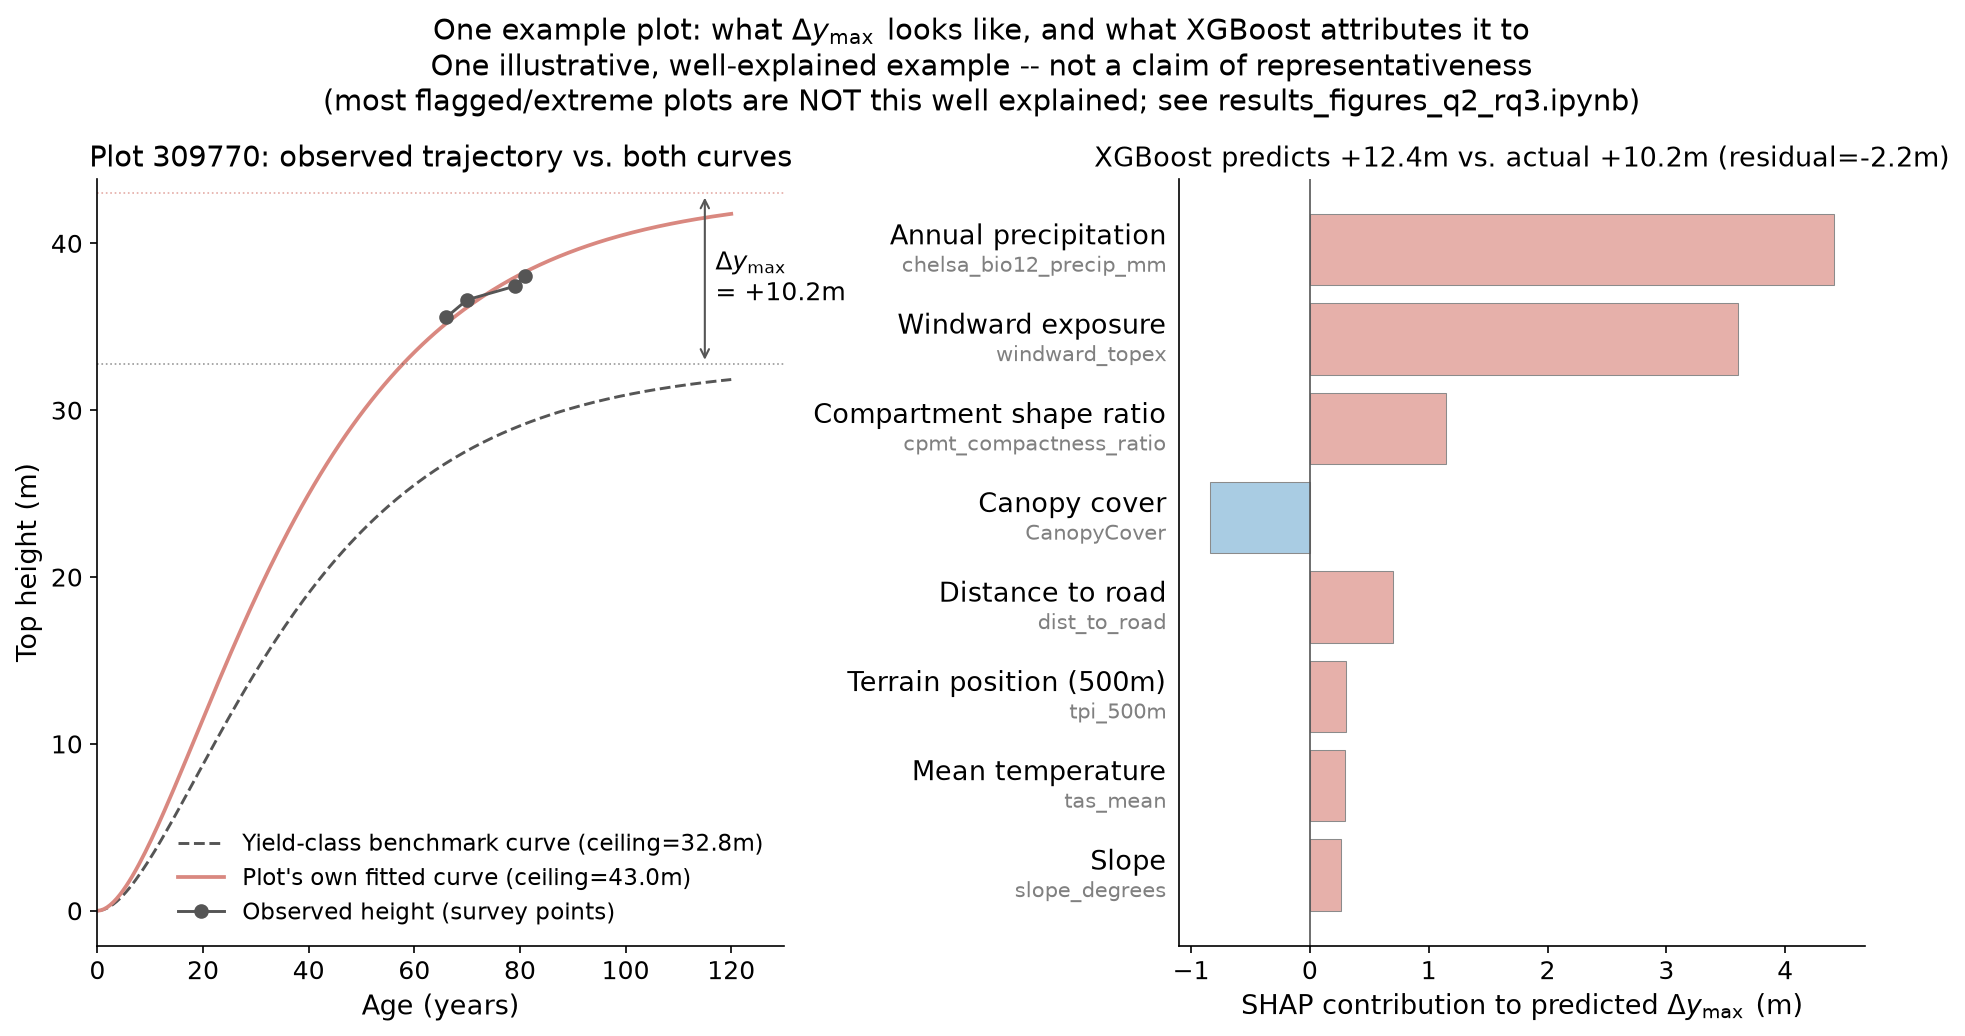

In [5]:
fig, (ax_trajectory, ax_shap) = plt.subplots(1, 2, figsize=(13, 7))

# --- Local pastel palette, this notebook only. NOT added to results_figures_style.py -- that
# file is shared by every figure in the dissertation and is currently being edited in another
# session; changing it here would both create a merge conflict and silently re-colour every
# other already-built figure. If a pastel palette is wanted project-wide, do that as its own
# deliberate change to results_figures_style.py once the other session's work has settled. ---
PASTEL_OWN_CURVE = "#D98880"      # soft coral (was COLOR_XGBOOST firebrick red)
PASTEL_POSITIVE = "#E6B0AA"       # soft rose (was DIVERGING_CMAP high end)
PASTEL_NEGATIVE = "#A9CCE3"       # soft blue (was DIVERGING_CMAP low end)

# Human-readable names for every possible Set4 SHAP column (not just the 8 shown for this one
# plot) -- sourced from documentation/variable_registry_av1_av2.csv's own descriptions, same
# convention already used in the Q1 results figures. Needed because which 8 features rank
# highest by |SHAP| differs per plot (this figure vs. the typical-plot appendix companion).
READABLE_NAME = {
    "CanopyCover": "Canopy cover",
    "time_since_thinning": "Time since thinning",
    "time_since_thinning_missing": "Never-thinned share",
    "recent_thinning_5yr": "Recent thinning (5yr)",
    "windward_topex": "Windward exposure",
    "gwa_wind_speed_50m": "Wind speed (50m)",
    "slope_degrees": "Slope",
    "tpi_500m": "Terrain position (500m)",
    "topex": "Terrain shelter (TOPEX)",
    "northness": "Northness (aspect)",
    "cpmt_compactness_ratio": "Compartment shape ratio",
    "dist_to_road": "Distance to road",
    "chelsa_bio12_precip_mm": "Annual precipitation",
    "tas_mean": "Mean temperature",
    "soilgrids_ph": "Soil pH",
    "dist_to_forest_perimeter": "Distance to forest edge",
    "ceh_subsurface_drainage=2.0": "Subsurface drainage class",
    "ceh_pedotope=2.0": "Soil pedotope class",
    "ceh_pedotope=8.0": "Soil pedotope class",
    "ceh_textural_composition=2.0": "Soil texture class",
}

# --- Panel A: observed trajectory (points connected by straight lines), the plot's own fitted
# curve, and the yield-class benchmark curve -- Delta y_max is the visible gap between the two
# curves' ceilings, not just a number. ---
age_range = np.linspace(0, 120, 200)
own_curve = y_max_hat * (1 - np.exp(-p4 * age_range)) ** p5
yldc_curve = y_max_yldc * (1 - np.exp(-p4 * age_range)) ** p5

ax_trajectory.plot(age_range, yldc_curve, linestyle="--", color=COLOR_NEUTRAL_EDGE, linewidth=1.4,
                    label=f"Yield-class benchmark curve (ceiling={y_max_yldc:.1f}m)")
ax_trajectory.plot(age_range, own_curve, linestyle="-", color=PASTEL_OWN_CURVE, linewidth=1.8,
                    label=f"Plot's own fitted curve (ceiling={y_max_hat:.1f}m)")
ax_trajectory.plot(trajectory["Age"], trajectory["Top_Height95"], marker="o", color="#555555",
                    linewidth=1.4, markersize=6, label="Observed height (survey points)")
ax_trajectory.axhline(y_max_hat, color=PASTEL_OWN_CURVE, linewidth=0.8, linestyle=":", alpha=0.7)
ax_trajectory.axhline(y_max_yldc, color=COLOR_NEUTRAL_EDGE, linewidth=0.8, linestyle=":", alpha=0.6)
ax_trajectory.annotate(
    "", xy=(115, y_max_hat), xytext=(115, y_max_yldc),
    arrowprops=dict(arrowstyle="<->", color="#555555", linewidth=1.0),
)
ax_trajectory.text(117, (y_max_hat + y_max_yldc) / 2, f"$\\Delta y_{{\\max}}$\n= {delta_y_max:+.1f}m",
                    fontsize=12, va="center")
ax_trajectory.set_xlim(0, 130)
ax_trajectory.set_xlabel("Age (years)", fontsize=13)
ax_trajectory.set_ylabel("Top height (m)", fontsize=13)
ax_trajectory.tick_params(labelsize=12)
ax_trajectory.set_title(f"Plot {EXAMPLE_PLOT_ID}: observed trajectory vs. both curves", fontsize=14)
ax_trajectory.legend(fontsize=11, frameon=False, loc="lower right")

# --- Panel B: SHAP attribution for this same plot -- how much of Delta y_max does XGBoost
# attribute to each Set4 variable. Pastel red/blue here (local override, see note above) rather
# than the sharp COLOR_XGBOOST/DIVERGING_CMAP tones used in results_figures_q2_rq3.ipynb's
# outlier-grid figure -- same sign convention (rose=positive push, blue=negative push), softer
# saturation only. ---
shap_row = shap_values.loc[shap_values["identification"] == EXAMPLE_PLOT_ID, shap_feature_columns].iloc[0]
top_features = shap_row.reindex(shap_row.abs().sort_values(ascending=False).index[:8])

bar_colors = [PASTEL_POSITIVE if v > 0 else PASTEL_NEGATIVE for v in top_features.values]

ax_shap.barh(range(len(top_features)), top_features.values, color=bar_colors, edgecolor="#8B8B8B", linewidth=0.5)
ax_shap.set_yticks(range(len(top_features)))
# Two-tier labels (readable name above, raw column name below in grey) instead of a single raw
# name -- same technique as the Q1 results figures: blank the real tick labels, place both lines
# by hand at each bar's y-position so each can have its own font size/colour.
ax_shap.set_yticklabels([])
ax_shap.tick_params(axis="y", length=0)
label_annotations = []
for i, raw_name in enumerate(top_features.index):
    label_annotations.append(ax_shap.annotate(
        READABLE_NAME.get(raw_name, raw_name), xy=(0, i), xycoords=("axes fraction", "data"),
        xytext=(-6, 6), textcoords="offset points", ha="right", va="center",
        fontsize=13, color="black"))
    label_annotations.append(ax_shap.annotate(
        raw_name, xy=(0, i), xycoords=("axes fraction", "data"),
        xytext=(-6, -8), textcoords="offset points", ha="right", va="center",
        fontsize=10, color="grey"))
ax_shap.invert_yaxis()
ax_shap.axvline(0, color="#555555", linewidth=0.8)
ax_shap.set_xlabel("SHAP contribution to predicted $\\Delta y_{\\max}$ (m)", fontsize=13)
ax_shap.tick_params(axis="x", labelsize=12)
# Panel title uses the RAW PREDICTION vs. actual, not the SHAP-value sum -- the sum excludes the
# model's base/expected value and gave a misleadingly clean "99.9% explained" figure in an
# earlier pass of this notebook (see the AUDIT note in the markdown cell above). The bars
# themselves are still each feature's own SHAP contribution; only this summary number changed.
example_predicted = predictions.loc[predictions["identification"] == EXAMPLE_PLOT_ID, "xgboost_predicted"].iloc[0]
example_residual = delta_y_max - example_predicted
ax_shap.set_title(f"XGBoost predicts {example_predicted:+.1f}m vs. actual {delta_y_max:+.1f}m "
                   f"(residual={example_residual:+.1f}m)",
                   fontsize=13)

fig.suptitle(f"One example plot: what $\\Delta y_{{\\max}}$ looks like, and what XGBoost attributes it to\n"
             "One illustrative, well-explained example -- not a claim of representativeness\n"
             "(most flagged/extreme plots are NOT this well explained; see results_figures_q2_rq3.ipynb)",
             fontsize=14)
plt.tight_layout()

# NOTE 2026-08-25: equalise panel widths WITHOUT shrinking Panel B, using a MEASURED gap instead
# of a guessed fraction. A fixed-fraction gap (tried: 6% of figure width) broke, because Panel
# B's two-tier labels are drawn via annotate() a fixed number of POINTS to the left of its axis
# box (xytext=(-6, ...)), not a fraction of whatever gap is chosen -- shrinking the gap moved
# Panel B's box left without moving the labels' required clearance, so they collided with Panel
# A. Instead: draw once, find the actual leftmost rendered x-position (in figure fraction) of
# every label text, and set the gap to exactly clear that, plus a small fixed buffer.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
leftmost_label_x = min(
    text.get_window_extent(renderer=renderer).transformed(fig.transFigure.inverted()).x0
    for text in label_annotations
)
pos_a = ax_trajectory.get_position()
pos_b = ax_shap.get_position()
buffer = 0.015  # small fixed gap between Panel A's right edge and the start of Panel B's labels
panel_width = pos_b.width
# Where Panel B's axis box (not its labels) must start, so its labels' left edge sits exactly
# `buffer` past Panel A's right edge, once Panel A is later repositioned to start at outer_margin.
label_offset_from_box = pos_b.x0 - leftmost_label_x  # how far left of its own box B's labels extend
combined_width = 2 * panel_width + buffer + label_offset_from_box
outer_margin = (1.0 - combined_width) / 2
new_x0_a = outer_margin
new_x0_b = outer_margin + panel_width + buffer + label_offset_from_box
ax_trajectory.set_position([new_x0_a, pos_a.y0, panel_width, pos_a.height])
ax_shap.set_position([new_x0_b, pos_b.y0, panel_width, pos_b.height])

fig.savefig(FIGURES_DIR / "q2_example_plot_curve.png", dpi=200, bbox_inches="tight")
plt.show()

## How typical is this example? -- quantified, not just asserted

The figure's own subtitle already says this is not a claim of representativeness. This section
puts a real number on that instead of leaving it as a bare assertion: where does plot 309770
actually sit in the population, and what does a genuinely typical plot look like (built below,
appendix candidate)?

In [6]:
non_flagged = predictions[~predictions["tukey_flagged"]].copy()

# Model residual = observed - predicted, same convention used everywhere else in this project
# (e.g. results_figures_q1_rq2b.ipynb's en_residual/xgb_residual). NOT the same thing as
# "explained_pct" above -- SHAP values sum to (prediction - base value) by construction, so
# explained_pct measures how close the prediction is to the actual value, which is what this
# residual measures directly and more robustly (explained_pct is unstable when the actual value
# is near zero).
non_flagged["residual"] = non_flagged["local_y_max_difference"] - non_flagged["xgboost_predicted"]
non_flagged["abs_residual"] = non_flagged["residual"].abs()
non_flagged = non_flagged.merge(survey_counts, on="identification")

example_abs_residual = non_flagged.loc[non_flagged["identification"] == EXAMPLE_PLOT_ID, "abs_residual"].iloc[0]
n_at_least_as_good = (non_flagged["abs_residual"] <= example_abs_residual).sum()
pct_at_least_as_good = n_at_least_as_good / len(non_flagged) * 100

print(f"Plot {EXAMPLE_PLOT_ID}'s own |residual| = {example_abs_residual:.2f}m")
print(f"{n_at_least_as_good:,} of {len(non_flagged):,} non-flagged plots ({pct_at_least_as_good:.1f}%) "
      f"are AT LEAST AS WELL-FIT as plot {EXAMPLE_PLOT_ID} -- i.e. it sits in roughly the best "
      f"{pct_at_least_as_good:.0f}th percentile, not a one-in-a-thousand cherry pick, but still "
      "well above the median.")
print("\nFull |residual| distribution among non-flagged plots:")
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    print(f"  {int(q*100)}th percentile: {non_flagged['abs_residual'].quantile(q):.2f}m")
print(f"  median |residual| = {non_flagged['abs_residual'].median():.2f}m "
      f"(vs. {example_abs_residual:.2f}m for the plot shown above)")

# --- A genuinely typical plot: |residual| close to the population MEDIAN, not the best-fit tail,
# same >=4-survey requirement so it is presentable the same way. ---
median_residual = non_flagged["abs_residual"].median()
non_flagged["distance_to_median_residual"] = (non_flagged["abs_residual"] - median_residual).abs()
typical_candidates = non_flagged[non_flagged["n_surveys"] >= 4].sort_values("distance_to_median_residual").head(5)
print("\nTypical-plot candidates (|residual| closest to the population median):")
print(typical_candidates[["identification", "cpmt", "local_y_max_difference", "xgboost_predicted",
                           "residual", "n_surveys"]].to_string(index=False))

Plot 309770's own |residual| = 2.17m
10,702 of 55,160 non-flagged plots (19.4%) are AT LEAST AS WELL-FIT as plot 309770 -- i.e. it sits in roughly the best 19th percentile, not a one-in-a-thousand cherry pick, but still well above the median.

Full |residual| distribution among non-flagged plots:
  10th percentile: 1.10m
  25th percentile: 2.81m
  50th percentile: 5.93m
  75th percentile: 10.37m
  90th percentile: 15.34m
  median |residual| = 5.93m (vs. 2.17m for the plot shown above)

Typical-plot candidates (|residual| closest to the population median):
 identification  cpmt  local_y_max_difference  xgboost_predicted  residual  n_surveys
         166972  2185               11.220736           5.289557  5.931178          4
         370241  2165               15.686154           9.755037  5.931117          4
         115248  2240                9.701078           3.769988  5.931090          4
         142148  2033               10.493299           4.561950  5.931349          4
        

## Appendix candidate: a genuinely typical plot (plot 166972)

Chosen as the closest-to-median-residual candidate with >=4 surveys. Ages 35-50, heights
26.0-37.3m (a presentable mid-maturity trajectory, not a broken/degenerate one). XGBoost predicts
only 5.3m of its actual 11.2m deviation -- roughly half -- with a more diffuse SHAP breakdown
(`chelsa_bio12_precip_mm`, `CanopyCover`, `recent_thinning_5yr`, `dist_to_road`,
`windward_topex`, no single dominant driver). This is what Q2's attribution mechanism looks like
for a typical plot, not the well-explained one used in the main text above -- worth pairing the
two figures directly in an appendix so a reader sees both ends, not just the flattering one.

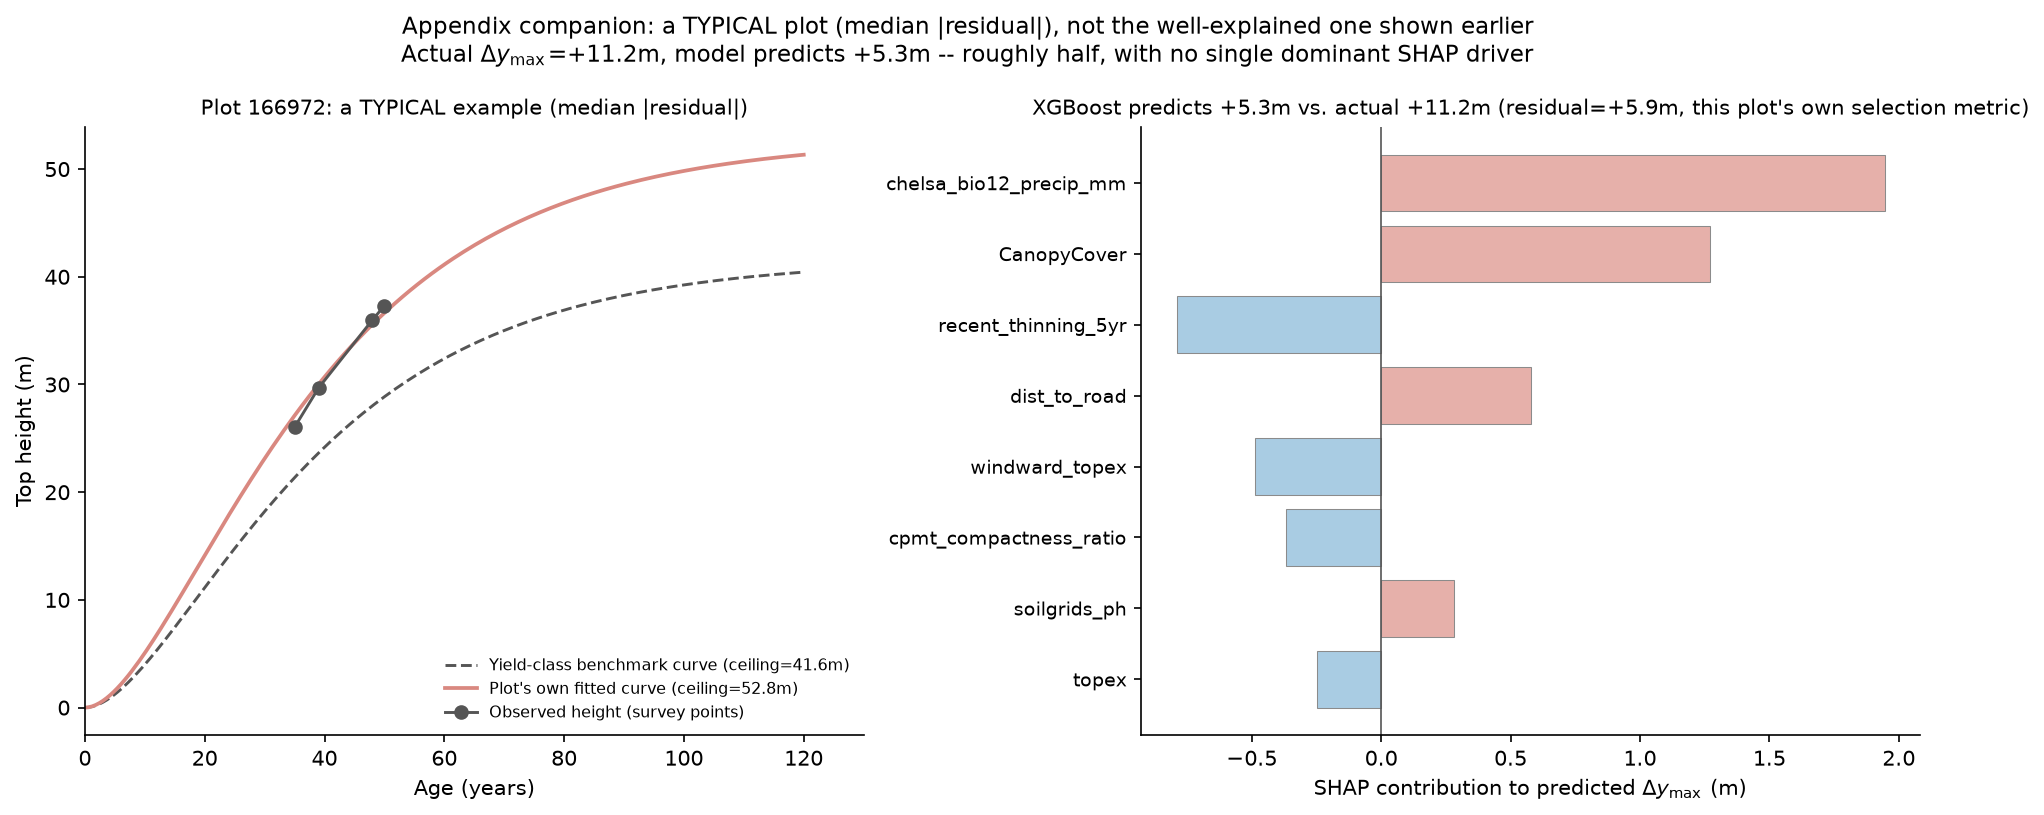

In [7]:
TYPICAL_PLOT_ID = 166972

typical_trajectory = growth_curve_table[growth_curve_table["identification"] == TYPICAL_PLOT_ID].sort_values("Age")
typical_p4, typical_p5 = typical_trajectory["p4"].iloc[0], typical_trajectory["p5"].iloc[0]
typical_y_max_yldc = typical_trajectory["y_max_yldc"].iloc[0]

typical_growth_term = (1 - np.exp(-typical_p4 * typical_trajectory["Age"])) ** typical_p5
typical_y_max_hat = (typical_trajectory["Top_Height95"] * typical_growth_term).sum() / (typical_growth_term ** 2).sum()
typical_delta_y_max = typical_y_max_hat - typical_y_max_yldc

fig, (ax_traj_typical, ax_shap_typical) = plt.subplots(1, 2, figsize=(13, 5.5))

typical_age_range = np.linspace(0, 120, 200)
typical_own_curve = typical_y_max_hat * (1 - np.exp(-typical_p4 * typical_age_range)) ** typical_p5
typical_yldc_curve = typical_y_max_yldc * (1 - np.exp(-typical_p4 * typical_age_range)) ** typical_p5

ax_traj_typical.plot(typical_age_range, typical_yldc_curve, linestyle="--", color=COLOR_NEUTRAL_EDGE, linewidth=1.4,
                      label=f"Yield-class benchmark curve (ceiling={typical_y_max_yldc:.1f}m)")
ax_traj_typical.plot(typical_age_range, typical_own_curve, linestyle="-", color=PASTEL_OWN_CURVE, linewidth=1.8,
                      label=f"Plot's own fitted curve (ceiling={typical_y_max_hat:.1f}m)")
ax_traj_typical.plot(typical_trajectory["Age"], typical_trajectory["Top_Height95"], marker="o", color="#555555",
                      linewidth=1.4, markersize=6, label="Observed height (survey points)")
ax_traj_typical.set_xlim(0, 130)
ax_traj_typical.set_xlabel("Age (years)")
ax_traj_typical.set_ylabel("Top height (m)")
ax_traj_typical.set_title(f"Plot {TYPICAL_PLOT_ID}: a TYPICAL example (median |residual|)", fontsize=10)
ax_traj_typical.legend(fontsize=7.5, frameon=False, loc="lower right")

typical_shap_row = shap_values.loc[shap_values["identification"] == TYPICAL_PLOT_ID, shap_feature_columns].iloc[0]
typical_top_features = typical_shap_row.reindex(typical_shap_row.abs().sort_values(ascending=False).index[:8])
typical_bar_colors = [PASTEL_POSITIVE if v > 0 else PASTEL_NEGATIVE for v in typical_top_features.values]

ax_shap_typical.barh(range(len(typical_top_features)), typical_top_features.values,
                      color=typical_bar_colors, edgecolor="#8B8B8B", linewidth=0.5)
ax_shap_typical.set_yticks(range(len(typical_top_features)))
ax_shap_typical.set_yticklabels(typical_top_features.index, fontsize=9)
ax_shap_typical.invert_yaxis()
ax_shap_typical.axvline(0, color="#555555", linewidth=0.8)
ax_shap_typical.set_xlabel("SHAP contribution to predicted $\\Delta y_{\\max}$ (m)")
# Same fix as the main-text figure above: title uses the raw prediction vs. actual (the metric
# this plot was actually SELECTED by -- closest |residual| to the population median), not the
# SHAP-value sum, so the number in the title matches the number used to choose this plot.
typical_predicted = predictions.loc[predictions["identification"] == TYPICAL_PLOT_ID, "xgboost_predicted"].iloc[0]
typical_residual = typical_delta_y_max - typical_predicted
ax_shap_typical.set_title(f"XGBoost predicts {typical_predicted:+.1f}m vs. actual {typical_delta_y_max:+.1f}m "
                           f"(residual={typical_residual:+.1f}m, this plot's own selection metric)", fontsize=10)

fig.suptitle(f"Appendix companion: a TYPICAL plot (median |residual|), not the well-explained one shown earlier\n"
             f"Actual $\\Delta y_{{\\max}}$={typical_delta_y_max:+.1f}m, model predicts {typical_predicted:+.1f}m -- "
             "roughly half, with no single dominant SHAP driver",
             fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "q2_example_plot_curve_typical_appendix.png", dpi=200)
plt.show()